# Projekat (iz predloga): koaliciona TU igra u mikro-mreži (PV + baterije + pooling)

Ovaj notebook **postavlja i rešava** problem iz predloga projekta:

1) Rešava „solo“ optimizaciju za svaku kuću \(i\):
\[
C^{solo}_i = \min \sum_t ig(c_{buy}(t)\,Import_i(t) - c_{sell}(t)\,Export_i(t)ig)
\]
uz bilans po satu:
\[
Import_i(t) + G_i(t) + Dis_i(t) = L_i(t) + Ch_i(t) + Export_i(t)
\]
i ograničenja baterije/SOC.

2) Rešava koalicioni (pooling) problem za svaku koaliciju \(S\):
\[
C^{coal}_S = \min \sum_t ig(c_{buy}(t)\,Import_S(t) - c_{sell}(t)\,Export_S(t)ig)
\]
gde je koalicija u stanju da interno razmenjuje energiju (idealno bez troška), pa mreža „vidi“ samo agregirani neto bilans.

3) Definiše karakterističnu funkciju (vrednost koalicije kao ušteda):
\[
v(S) = \Big(\sum_{i\in S} C^{solo}_i\Big) - C^{coal}_S
\]

4) Računa raspodele: **Shapley**, **core test**, i **least-core** (min \(
arepsilon\)).

> Napomena: Primer ispod generiše sintetičke profile (24h). U praksi samo zameni `L` i `G` realnim profilima.


## 0) Importi

In [1]:
# !pip -q install numpy pandas matplotlib scipy

import itertools
import math
from typing import Dict, FrozenSet, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog


## 1) Podaci (scenario iz predloga)

- n=5 kuća
- PV: 2 kuće imaju PV
- baterija: 1 kuća ima bateriju
- TOU cene: skuplje veče


In [2]:
np.random.seed(4)

# --- osnovni scenario (možeš menjati) ---
n = 5
T = 24
hours = np.arange(T)
players = list(range(1, n+1))

# TOU cene (primer)
cbuy = 0.12*np.ones(T)
cbuy[(hours>=18) & (hours<=22)] = 0.22
cbuy[(hours>=7)  & (hours<=9)]  = 0.18
csell = 0.06*np.ones(T)

# Ko ima PV / bateriju (primer: kuće 1 i 3 imaju PV, kuća 2 ima bateriju)
has_pv = np.array([1, 0, 1, 1, 0], dtype=bool)
has_batt = np.array([0, 1, 0, 1, 0], dtype=bool)

# Parametri baterije (po kući)
E = np.zeros(n)          # kapacitet [kWh]
Pch = np.zeros(n)        # max punjenje [kW] (po satu -> kWh)
Pdis = np.zeros(n)       # max pražnjenje [kW]
eta_ch = 0.95
eta_dis = 0.95

E[has_batt] = 6.0
Pch[has_batt] = 2.0
Pdis[has_batt] = 2.0

SOC0 = 0.5*E  # početni SOC (0 za kuće bez baterije)

# --- sintetički profili L_i(t), G_i(t) ---
def gaussian(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2)

L = np.zeros((n, T))  # load
G = np.zeros((n, T))  # PV generation

for i in range(n):
    scale_L = np.random.uniform(0.8, 1.4)
    base = 0.35 + 0.08*np.random.randn(T)
    morning = 0.9*gaussian(hours, mu=np.random.uniform(7.0, 8.5), sigma=1.2)
    evening = 1.2*gaussian(hours, mu=np.random.uniform(19.0, 21.0), sigma=1.8)
    L[i] = np.clip(scale_L*(base + morning + evening), 0.05, None)

    if has_pv[i]:
        scale_G = np.random.uniform(0.9, 1.4)
        pv = 1.8*gaussian(hours, mu=np.random.uniform(12.0, 13.5), sigma=2.2)
        G[i] = np.clip(scale_G*pv + 0.02*np.random.randn(T), 0.0, None)
    else:
        G[i] = 0.0

df = pd.DataFrame({"hour": hours, "cbuy": cbuy, "csell": csell})
for i in range(n):
    df[f"L{i+1}"] = L[i]
    df[f"G{i+1}"] = G[i]
df.head()


,hour,cbuy,csell,L1,G1,L2,G2,L3,G3,L4,G4,L5,G5
0,0,0.12,0.06,0.532804,0.026386,0.198710,0.0,0.516656,0.005152,0.595242,0.000000,0.303539,0.0
1,1,0.12,0.06,0.488045,0.012229,0.335635,0.0,0.255376,0.000000,0.492756,0.017908,0.293262,0.0
2,2,0.12,0.06,0.592778,0.000000,0.332495,0.0,0.238622,0.000000,0.505960,0.000000,0.293551,0.0
3,3,0.12,0.06,0.602498,0.000000,0.318853,0.0,0.342228,0.000000,0.565248,0.000000,0.320174,0.0
4,4,0.12,0.06,0.648778,0.040767,0.476574,0.0,0.242211,0.000000,0.402020,0.000000,0.312290,0.0


In [ ]:
from scipy.optimize import linprog

def _linprog_solve(c, A_eq=None, b_eq=None, A_ub=None, b_ub=None, bounds=None):
    res = linprog(
        c,
        A_ub=A_ub, b_ub=b_ub,
        A_eq=A_eq, b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )
    if not res.success:
        raise RuntimeError("LP failed: " + res.message)
    return res

def solve_solo_schedule(i: int):
    """
    Reši solo LP za domaćinstvo i (1..n) i vrati schedule dict:
    Import, Export, Ch, Dis, SOC (SOC dužine T+1).
    """
    idx = i - 1
    hasB = bool(has_batt[idx])

    # Var order:
    # Import(0..T-1), Export(0..T-1), Ch(0..T-1), Dis(0..T-1), SOC(0..T)
    n_imp = T
    n_exp = T
    n_ch  = T
    n_dis = T
    n_soc = T + 1

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # Objective: sum cbuy*Import - csell*Export
    c = np.zeros(nvar)
    c[offset_imp:offset_imp+T] = cbuy
    c[offset_exp:offset_exp+T] = -csell

    A_eq = []
    b_eq = []

    # Energy balance for each t:
    # Import - Export - Ch + Dis = L - G
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0
        row[offset_ch+t]  = -1.0
        row[offset_dis+t] = 1.0
        A_eq.append(row)
        b_eq.append(L[idx, t] - G[idx, t])

    # SOC dynamics:
    # SOC[t+1] - SOC[t] - eta_ch*Ch[t] + Dis[t]/eta_dis = 0
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_soc+t+1] = 1.0
        row[offset_soc+t]   = -1.0
        row[offset_ch+t]    = -eta_ch
        row[offset_dis+t]   = 1.0/eta_dis
        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(nvar); row[offset_soc+0] = 1.0
    A_eq.append(row); b_eq.append(SOC0[idx])

    # Terminal SOC = initial
    row = np.zeros(nvar); row[offset_soc+T] = 1.0
    A_eq.append(row); b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Bounds
    bounds = []
    bounds += [(0, None)] * T  # Import
    bounds += [(0, None)] * T  # Export

    # Ch, Dis
    for t in range(T):
        bounds.append((0, Pch[idx] if hasB else 0.0))
    for t in range(T):
        bounds.append((0, Pdis[idx] if hasB else 0.0))

    # SOC
    for t in range(T+1):
        bounds.append((0, E[idx] if hasB else 0.0))

    res = _linprog_solve(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
    x = res.x

    sched = {
        "Import": x[offset_imp:offset_imp+T],
        "Export": x[offset_exp:offset_exp+T],
        "Ch":     x[offset_ch:offset_ch+T],
        "Dis":    x[offset_dis:offset_dis+T],
        "SOC":    x[offset_soc:offset_soc+T+1],
    }
    return sched

# --- Izračunaj schedule za svaku kuću ---
solo_sched = {}
for i in range(1, n+1):
    solo_sched[i] = solve_solo_schedule(i)

# --- Pripremi 3 serije za histogram po kući ---
pv_gen = {i: G[i-1].copy() for i in range(1, n+1)}  # ako nema PV već je 0 iz tvoje generacije
batt_balance = {}
grid_import = {}

for i in range(1, n+1):
    sch = solo_sched[i]
    # bilans baterije: + prazni, - puni
    if has_batt[i-1]:
        batt_balance[i] = sch["Dis"] - sch["Ch"]
    else:
        batt_balance[i] = np.zeros(T)
    # uvoz iz mreže
    grid_import[i] = sch["Import"]

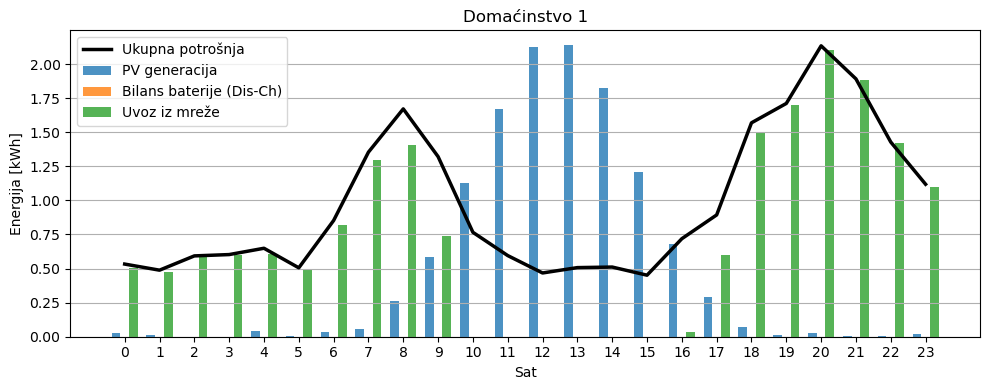

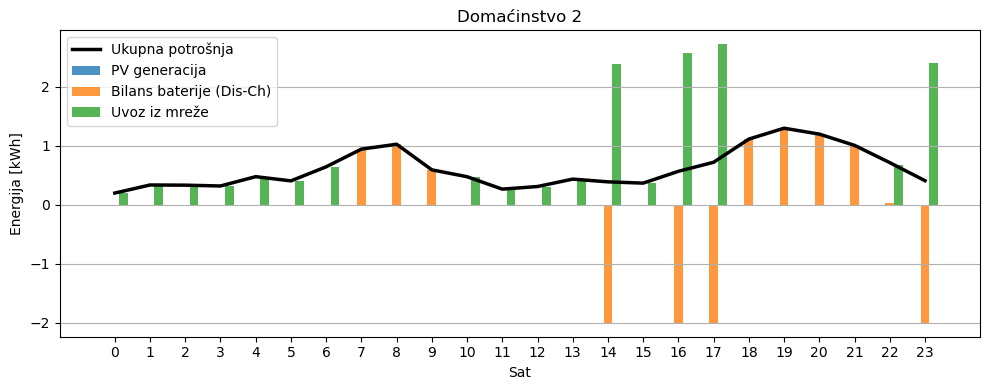

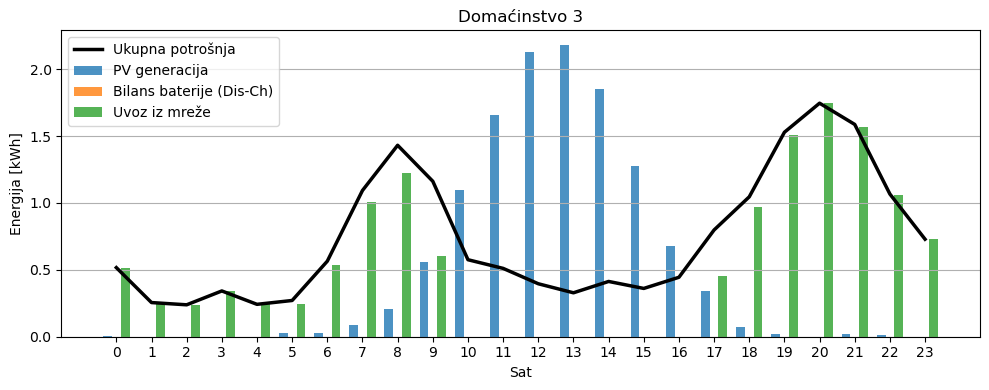

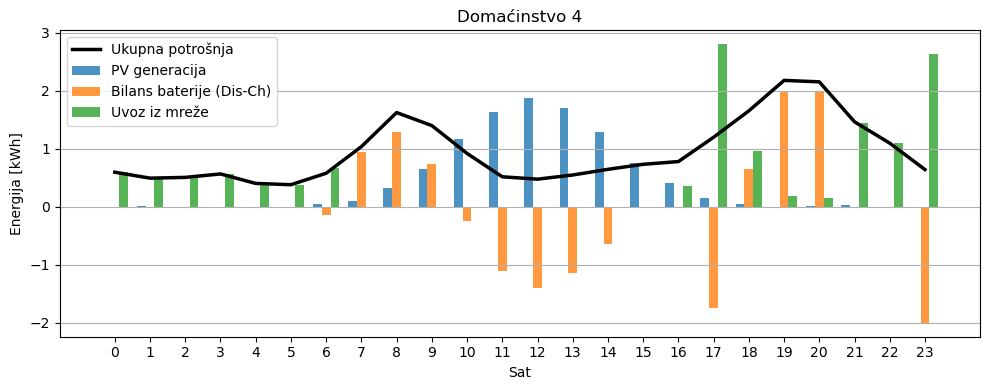

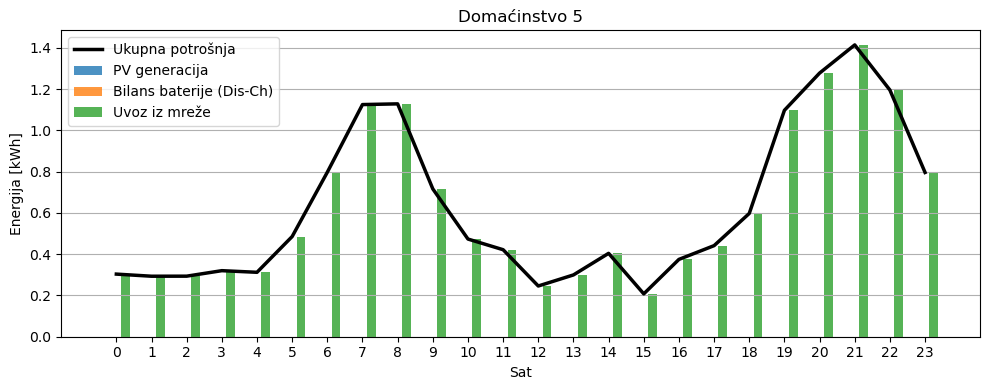

In [20]:
# --- Plot: jedan histogram po kući sa tri kategorije + linija potrošnje ---
width = 0.25

for i in range(1, n+1):

    pv = pv_gen[i]
    batt = batt_balance[i]
    grid = grid_import[i]

    # ukupna potrošnja domaćinstva
    total_load = L[i-1]

    x = hours

    plt.figure(figsize=(10,4))

    plt.bar(x - width, pv, width=width, label="PV generacija", alpha=0.8)
    plt.bar(x, batt, width=width, label="Bilans baterije (Dis-Ch)", alpha=0.8)
    plt.bar(x + width, grid, width=width, label="Uvoz iz mreže", alpha=0.8)

    # linija ukupne potrošnje
    plt.plot(x, total_load, color="black", linewidth=2.5, label="Ukupna potrošnja")

    plt.title(f"Domaćinstvo {i}")
    plt.xlabel("Sat")
    plt.ylabel("Energija [kWh]")
    plt.xticks(hours)

    plt.legend()
    plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()

### Grafici profila

## 2) LP modeli

### 2.1 Solo LP (za kuću i)
Varijable po satu: Import, Export, Ch, Dis, SOC.

Bilans: `Import + G + Dis = L + Ch + Export`.
SOC dinamika (korak 1h): `SOC[t+1] = SOC[t] + eta_ch*Ch[t] - Dis[t]/eta_dis`.

### 2.2 Koalicioni LP (pooling)
Baterije su lokalne (svaka kuća upravlja svojom), ali mreža vidi samo agregat:

`Import_S - Export_S = sum_i (L_i - G_i + Ch_i - Dis_i)`

što implementira „idealni pooling“ (viškovi PV jedne kuće mogu da pokriju deficit druge u istom satu).


In [6]:
def _linprog_solve(c, A_eq=None, b_eq=None, A_ub=None, b_ub=None, bounds=None):
    res = linprog(
        c,
        A_ub=A_ub, b_ub=b_ub,
        A_eq=A_eq, b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )
    if not res.success:
        raise RuntimeError("LP failed: " + res.message)
    return res

def solve_solo(i: int) -> Tuple[float, Dict[str, np.ndarray]]:
    """Solo optimization for household i (1..n). Returns (cost, schedule dict)."""
    idx = i-1
    hasB = bool(has_batt[idx])
    T = len(hours)

    # Variable ordering:
    # [Import(0..T-1), Export(0..T-1), Ch(0..T-1), Dis(0..T-1), SOC(0..T-1)]
    # SOC is defined at each hour boundary (T points). We'll store SOC(0..T-1) and add constraints between them.
    # Simpler: SOC at times 0..T-1 and enforce SOC[t+1] using SOC[t] by extending SOC length T (T+1 points).
    # We'll do SOC length T+1.
    n_imp = T
    n_exp = T
    n_ch  = T
    n_dis = T
    n_soc = T+1

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # Objective: sum cbuy*Import - csell*Export
    c = np.zeros(nvar)
    c[offset_imp:offset_imp+T] = cbuy
    c[offset_exp:offset_exp+T] = -csell

    # Equality constraints: energy balance for each t
    A_eq = []
    b_eq = []
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0
        row[offset_ch+t]  = -1.0
        row[offset_dis+t] = 1.0
        # constants: +G -L
        A_eq.append(row)
        b_eq.append(L[idx, t] - G[idx, t])  # move to RHS: Import - Export - Ch + Dis = L - G

    # SOC dynamics for t=0..T-1:
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_soc+t+1] = 1.0
        row[offset_soc+t]   = -1.0
        # SOC[t+1] - SOC[t] - eta_ch*Ch[t] + Dis[t]/eta_dis = 0
        row[offset_ch+t]  = -eta_ch
        row[offset_dis+t] = 1.0/eta_dis
        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(nvar)
    row[offset_soc+0] = 1.0
    A_eq.append(row)
    b_eq.append(SOC0[idx])

    # Terminal SOC = initial (fair comparison); only if has battery (else it's 0 anyway)
    row = np.zeros(nvar)
    row[offset_soc+T] = 1.0
    A_eq.append(row)
    b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Bounds
    bounds = []
    # Import, Export >=0
    bounds += [(0, None)]*T
    bounds += [(0, None)]*T
    # Ch, Dis bounds (0..P)
    for t in range(T):
        bounds.append((0, Pch[idx] if hasB else 0.0))
    for t in range(T):
        bounds.append((0, Pdis[idx] if hasB else 0.0))
    # SOC bounds
    for t in range(T+1):
        bounds.append((0, E[idx] if hasB else 0.0))

    res = _linprog_solve(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)

    x = res.x
    sched = {
        "Import": x[offset_imp:offset_imp+T],
        "Export": x[offset_exp:offset_exp+T],
        "Ch": x[offset_ch:offset_ch+T],
        "Dis": x[offset_dis:offset_dis+T],
        "SOC": x[offset_soc:offset_soc+T+1],
    }
    return float(res.fun), sched

def solve_coalition(S: FrozenSet[int]) -> Tuple[float, Dict[str, np.ndarray]]:
    """Coalition pooling optimization for coalition S. Returns (cost, schedules)."""
    members = sorted(S)
    m = len(members)
    T = len(hours)

    # Vars:
    # ImportS(T), ExportS(T),
    # For each member k: Ch_k(T), Dis_k(T), SOC_k(T+1)
    n_imp = T
    n_exp = T
    n_ch  = m*T
    n_dis = m*T
    n_soc = m*(T+1)

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # Objective: sum cbuy*ImportS - csell*ExportS
    c = np.zeros(nvar)
    c[offset_imp:offset_imp+T] = cbuy
    c[offset_exp:offset_exp+T] = -csell

    A_eq = []
    b_eq = []

    # Aggregated energy balance each t:
    # ImportS - ExportS - sum_k Ch_k + sum_k Dis_k = sum_k (L_k - G_k)
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0

        rhs = 0.0
        for k, i in enumerate(members):
            idx = i-1
            rhs += (L[idx, t] - G[idx, t])
            row[offset_ch + k*T + t]  = -1.0
            row[offset_dis + k*T + t] = 1.0

        A_eq.append(row)
        b_eq.append(rhs)

    # SOC dynamics per member
    for k, i in enumerate(members):
        idx = i-1
        for t in range(T):
            row = np.zeros(nvar)
            soc0 = offset_soc + k*(T+1)
            row[soc0 + t+1] = 1.0
            row[soc0 + t]   = -1.0
            row[offset_ch + k*T + t]  = -eta_ch
            row[offset_dis + k*T + t] = 1.0/eta_dis
            A_eq.append(row)
            b_eq.append(0.0)

        # initial SOC
        row = np.zeros(nvar)
        row[(offset_soc + k*(T+1) + 0)] = 1.0
        A_eq.append(row)
        b_eq.append(SOC0[idx])

        # terminal SOC = initial
        row = np.zeros(nvar)
        row[(offset_soc + k*(T+1) + T)] = 1.0
        A_eq.append(row)
        b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Bounds
    bounds = []
    bounds += [(0, None)]*T  # ImportS
    bounds += [(0, None)]*T  # ExportS

    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        for t in range(T):
            bounds.append((0, Pch[idx] if hasB else 0.0))
        for t in range(T):
            bounds.append((0, Pdis[idx] if hasB else 0.0))
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        for t in range(T+1):
            bounds.append((0, E[idx] if hasB else 0.0))

    res = _linprog_solve(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)

    x = res.x
    sched = {
        "ImportS": x[offset_imp:offset_imp+T],
        "ExportS": x[offset_exp:offset_exp+T],
    }
    # per member schedules
    for k, i in enumerate(members):
        sched[f"Ch{i}"]  = x[offset_ch + k*T : offset_ch + (k+1)*T]
        sched[f"Dis{i}"] = x[offset_dis + k*T: offset_dis + (k+1)*T]
        soc0 = offset_soc + k*(T+1)
        sched[f"SOC{i}"] = x[soc0: soc0+T+1]

    return float(res.fun), sched


## 3) Solo i koalicioni troškovi + karakteristična funkcija v(S)

In [7]:
# Solo troškovi
C_solo = {}
solo_sched = {}
for i in players:
    c, sch = solve_solo(i)
    C_solo[i] = c
    solo_sched[i] = sch

C_solo


{1: 2.804692204345432,
 2: 1.9064032036718201,
 3: 1.9723697501626023,
 4: 1.9667923620540209,
 5: 2.5395673535382812}

In [8]:
def powerset(players: List[int]) -> List[FrozenSet[int]]:
    out = []
    n = len(players)
    for r in range(1, n+1):
        for comb in itertools.combinations(players, r):
            out.append(frozenset(comb))
    return out

coalitions = powerset(players)

# Koalicioni troškovi
C_coal = {}
for S in coalitions:
    c, _ = solve_coalition(S)
    C_coal[S] = c

# v(S) = sum_{i in S} C_solo_i - C_coal_S
v = {}
for S in coalitions:
    v[S] = sum(C_solo[i] for i in S) - C_coal[S]

vN = v[frozenset(players)]
print("v(N) (ukupna usteda velike koalicije) =", vN)


v(N) (ukupna usteda velike koalicije) = -1.0730060848408538


In [9]:
# tabela koalicija
def coalition_str(S: FrozenSet[int]) -> str:
    return "{" + ",".join(map(str, sorted(S))) + "}"

df_v = pd.DataFrame([{
    "S": coalition_str(S),
    "|S|": len(S),
    "C_coal(S)": C_coal[S],
    "sum C_solo": sum(C_solo[i] for i in S),
    "v(S) = savings": v[S]
} for S in sorted(coalitions, key=lambda s: (len(s), sorted(s)))])
df_v


,S,|S|,C_coal(S),sum C_solo,v(S) = savings
0,{1},1,2.804692,2.804692,0.000000e+00
1,{2},1,1.906403,1.906403,0.000000e+00
2,{3},1,1.972370,1.972370,0.000000e+00
3,{4},1,1.966792,1.966792,0.000000e+00
4,{5},1,2.539567,2.539567,0.000000e+00
5,"{1,2}",2,5.109114,4.711095,-3.980191e-01
6,"{1,3}",2,4.774904,4.777062,2.158181e-03
7,"{1,4}",2,5.590654,4.771485,-8.191691e-01
8,"{1,5}",2,5.227837,5.344260,1.164223e-01
9,"{2,3}",2,4.255767,3.878773,-3.769940e-01


## 4) Shapley vrednost (tačno za n ≤ 10)

In [10]:
def all_permutations(players: List[int]):
    return itertools.permutations(players)

def shapley_value(players: List[int], v: Dict[FrozenSet[int], float]) -> Dict[int, float]:
    n = len(players)
    phi = {i: 0.0 for i in players}
    perms = list(all_permutations(players))
    fact = math.factorial(n)

    for pi in perms:
        S = frozenset()
        for i in pi:
            before = S
            after = frozenset(set(S) | {i})
            v_before = v.get(before, 0.0)  # v(empty)=0
            v_after = v[after]
            phi[i] += (v_after - v_before)
            S = after

    for i in players:
        phi[i] /= fact
    return phi

phi = shapley_value(players, v)
print("sum(phi) =", sum(phi.values()), "  v(N) =", vN)
phi


sum(phi) = -1.0730060848408536   v(N) = -1.0730060848408538


{1: -0.24206413859046894,
 2: -0.1387978290715625,
 3: -0.05175111907890435,
 4: -0.43371129549003873,
 5: -0.206681702609879}

In [11]:
df_alloc = pd.DataFrame({
    "player": players,
    "C_solo [€]": [C_solo[i] for i in players],
    "Shapley x_i [€]": [phi[i] for i in players],
})
df_alloc


,player,C_solo [€],Shapley x_i [€]
0,1,2.804692,-0.242064
1,2,1.906403,-0.138798
2,3,1.972370,-0.051751
3,4,1.966792,-0.433711
4,5,2.539567,-0.206682


## 5) Core test + blokirajuće koalicije

In [12]:
def core_violations(players: List[int], v: Dict[FrozenSet[int], float], x: Dict[int, float]):
    viol = []
    for S in powerset(players):
        lhs = sum(x[i] for i in S)
        rhs = v[S]
        deficit = rhs - lhs  # >0 znači kršenje core uslova
        if deficit > 1e-9:
            viol.append((S, lhs, rhs, deficit))
    viol.sort(key=lambda t: t[3], reverse=True)
    return viol

viol_shapley = core_violations(players, v, phi)
print("Broj core-kršenja (Shapley):", len(viol_shapley))
if viol_shapley:
    S, lhs, rhs, deficit = viol_shapley[0]
    print("Najgore kršenje:", coalition_str(S), "deficit =", deficit)


Broj core-kršenja (Shapley): 21
Najgore kršenje: {2,3,4,5} deficit = 0.7993236634604155


In [13]:
df_viol = pd.DataFrame([{
    "S": coalition_str(S),
    "sum x_i": lhs,
    "v(S)": rhs,
    "deficit": deficit
} for (S, lhs, rhs, deficit) in viol_shapley[:10]])
df_viol


,S,sum x_i,v(S),deficit
0,"{2,3,4,5}",-0.830942,-3.161828e-02,0.799324
1,"{1,2,3,4}",-0.866324,-1.439579e-01,0.722367
2,"{1,2,4}",-0.814573,-1.581166e-01,0.656457
3,"{1,3,5}",-0.500497,1.373158e-01,0.637813
4,"{2,4}",-0.572509,8.881784e-16,0.572509
5,"{1,5}",-0.448746,1.164223e-01,0.565168
6,{4},-0.433711,0.000000e+00,0.433711
7,"{3,5}",-0.258433,1.373158e-01,0.395749
8,"{2,4,5}",-0.779191,-3.974545e-01,0.381736
9,"{1,2,3,5}",-0.639295,-2.578591e-01,0.381436


In [14]:
print("v(N) =", v[frozenset(players)])

v(N) = -1.0730060848408538


## 6) Least core (min ε) kao LP

In [15]:
def least_core(players: List[int], v: Dict[FrozenSet[int], float]):
    n = len(players)
    coalitions = powerset(players)

    # variables: x1..xn, eps
    c = np.zeros(n+1)
    c[-1] = 1.0  # minimize eps

    A_ub = []
    b_ub = []

    # sum_{i in S} x_i + eps >= v(S)  <=>  -sum x_i - eps <= -v(S)
    for S in coalitions:
        row = np.zeros(n+1)
        for i in S:
            row[i-1] = -1.0
        row[-1] = -1.0
        A_ub.append(row)
        b_ub.append(-v[S])

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # efficiency: sum x_i = v(N)
    A_eq = np.zeros((1, n+1))
    A_eq[0, :n] = 1.0
    b_eq = np.array([v[frozenset(players)]])

    # ✅ KLJUČNO: x_i može biti i negativan; eps >= 0
    bounds = [(None, None)]*n + [(0, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(res.message)

    x = {players[i]: float(res.x[i]) for i in range(n)}
    eps = float(res.x[-1])
    return x, eps

In [16]:
x_lc, eps_lc = least_core(players, v)
print("eps* =", eps_lc)
print("x_lc =", x_lc)
print("sum(x_lc) =", sum(x_lc.values()), " v(N) =", v[frozenset(players)])

eps* = 0.6978643550695924
x_lc = {1: -0.3435234469812922, 2: -0.3951748554823631, 3: 0.014158746057688631, 4: -0.11728265701974469, 5: -0.2311838714151424}
sum(x_lc) = -1.0730060848408538  v(N) = -1.0730060848408538


In [17]:
df_compare = pd.DataFrame({
    "player": players,
    "Shapley": [phi[i] for i in players],
    "Least-core": [x_lc[i] for i in players],
})
df_compare


,player,Shapley,Least-core
0,1,-0.242064,-0.343523
1,2,-0.138798,-0.395175
2,3,-0.051751,0.014159
3,4,-0.433711,-0.117283
4,5,-0.206682,-0.231184


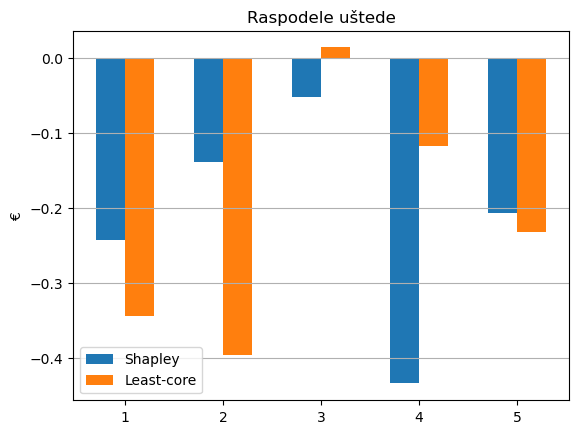

In [18]:
plt.figure()
xpos = np.arange(n)
plt.bar(xpos-0.15, df_compare["Shapley"], width=0.3, label="Shapley")
plt.bar(xpos+0.15, df_compare["Least-core"], width=0.3, label="Least-core")
plt.xticks(xpos, [str(i) for i in players])
plt.ylabel("€")
plt.title("Raspodele uštede")
plt.grid(True, axis="y")
plt.legend()
plt.show()


## 7) Dve heuristike (iz predloga): equal split, proportional PV

In [19]:
def equal_split(players: List[int], vN: float) -> Dict[int, float]:
    return {i: vN/len(players) for i in players}

def proportional_pv(players: List[int], vN: float, G: np.ndarray) -> Dict[int, float]:
    totals = np.array([G[i-1].sum() for i in players], dtype=float)
    if totals.sum() <= 1e-12:
        return equal_split(players, vN)
    shares = totals / totals.sum()
    return {players[k]: float(vN*shares[k]) for k in range(len(players))}

def summarize_allocation(name: str, x: Dict[int, float]):
    viol = core_violations(players, v, x)
    worst = viol[0][3] if viol else 0.0
    print(f"{name}: core violations = {len(viol)}, worst deficit = {worst:.6f}")

x_eq = equal_split(players, vN)
x_pv = proportional_pv(players, vN, G)

summarize_allocation("Equal split", x_eq)
summarize_allocation("Prop PV", x_pv)


Equal split: core violations = 21, worst deficit = 0.826787
Prop PV: core violations = 19, worst deficit = 0.929048
